In [5]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "city_day.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ankushpanday1/air-quality-data-in-india-2015-2024",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print(df.head())

Using Colab cache for faster access to the 'air-quality-data-in-india-2015-2024' dataset.
        City    Datetime  PM2.5   PM10     NO   NO2    NOx   NH3    CO   SO2  \
0      Delhi  2015-01-01  153.3  241.7  182.9  33.0   81.3  38.5  1.87  64.5   
1     Mumbai  2015-01-01   70.5  312.7  195.0  42.0  122.5  31.5  7.22  83.8   
2    Chennai  2015-01-01  174.1  275.4   56.2  68.8  230.9  28.5  8.56  60.8   
3    Kolkata  2015-01-01  477.2  543.9   14.1  76.4  225.9  45.6  2.41  42.1   
4  Bangalore  2015-01-01  171.6  117.7  123.3  12.4   61.9  49.7  1.26  79.7   

      O3  Benzene  Toluene  Xylene    AQI    AQI_Bucket  
0   83.6    18.93    20.81    8.32  204.5        Severe  
1  108.0     2.01    19.41    2.86   60.9  Satisfactory  
2   43.9    19.07    10.19    9.63  486.5        Severe  
3  171.1     9.31    11.65    9.39  174.4     Very Poor  
4  164.3     6.04    12.74    9.59  489.7          Good  


In [8]:
df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  object 
 1   Datetime    18265 non-null  object 
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  Benzene     18265 non-null  float64
 12  Toluene     18265 non-null  float64
 13  Xylene      18265 non-null  float64
 14  AQI         18265 non-null  float64
 15  AQI_Bucket  18265 non-null  object 
dtypes: float64(13), object(3)
memory usage: 2.2+ MB


(None,
               PM2.5          PM10            NO           NO2           NOx  \
 count  18265.000000  18265.000000  18265.000000  18265.000000  18265.000000   
 mean     250.597695    299.442491    100.481035     75.415916    125.964079   
 std      144.460292    173.479906     57.774795     43.460066     72.403893   
 min        0.000000      0.000000      0.000000      0.000000      0.000000   
 25%      125.700000    150.100000     50.600000     37.700000     63.100000   
 50%      251.000000    300.300000    100.200000     76.000000    126.200000   
 75%      376.200000    450.000000    151.000000    113.200000    188.900000   
 max      499.900000    600.000000    200.000000    150.000000    250.000000   
 
                 NH3            CO           SO2            O3       Benzene  \
 count  18265.000000  18265.000000  18265.000000  18265.000000  18265.000000   
 mean      25.065042      5.002451     49.835839    100.406740     10.070033   
 std       14.452019      2.889

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [11]:
# Filter for Mumbai and Sort
df = df[df['City'] == 'Mumbai'].copy()
df['Date'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Date')

In [ ]:
print(df.columns) 
df.head()

Index(['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket',
       'Date'],
      dtype='object')


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Date
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory,2015-01-01
6,Mumbai,2015-01-02,59.2,335.7,182.1,143.8,207.3,44.8,5.81,6.4,145.5,7.99,29.18,7.11,254.9,Good,2015-01-02
11,Mumbai,2015-01-03,191.0,200.5,21.5,141.3,235.8,8.6,8.54,89.0,129.8,10.37,4.99,8.19,37.9,Poor,2015-01-03
16,Mumbai,2015-01-04,177.3,30.8,164.9,149.3,83.5,37.4,8.63,30.7,75.7,3.54,16.20,6.57,78.5,Severe,2015-01-04
21,Mumbai,2015-01-05,335.4,582.7,144.2,37.2,130.3,22.9,6.83,91.6,30.9,8.89,8.25,3.77,30.7,Very Poor,2015-01-05


In [14]:
# --- STEP 2: Missing Value Inspection (The "Sanity Check") ---
# PROJECT NOTE: We inspect missing values to decide between Deletion (dropna) vs Imputation.
# Deletion is bad for Time Series because it breaks the daily sequence needed for forecasting.
print("\n>>> Missing Value Report (Before Cleaning):")
missing_report = df.isnull().sum()
print(missing_report[missing_report > 0])


>>> Missing Value Report (Before Cleaning):
Series([], dtype: int64)


In [15]:
# --- STEP 3: Smart Imputation ---
# METHOD: Linear Interpolation
# LOGIC: If Monday is 100 and Wednesday is 120, we assume Tuesday is 110.
# This preserves data volume better than dropping rows.
df = df.interpolate(method='linear', limit_direction='both')

/tmp/ipython-input-2505622736.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit_direction='both')


In [16]:
# Drop any remaining NaNs (e.g., if the very first row is missing, interpolate can't fix it)
initial_rows = len(df)
df = df.dropna()
print(f"\n>>> Data Cleaning Complete. Retained {len(df)}/{initial_rows} days.")


>>> Data Cleaning Complete. Retained 3653/3653 days.


In [17]:
# Drop any remaining NaNs (e.g., if the very first row is missing, interpolate can't fix it)
initial_rows = len(df)
df = df.dropna()
print(f"\n>>> Data Cleaning Complete. Retained {len(df)}/{initial_rows} days.")


>>> Data Cleaning Complete. Retained 3653/3653 days.


In [21]:
# Split Date: Train on Past (2015-2022), Test on Future (2023-2024)
split_date = pd.to_datetime('2023-01-01')
train = df[df['Date'] < split_date]
test = df[df['Date'] >= split_date]

# --- STEP 4: Feature Engineering (Forecasting Setup) ---
# GOAL: Predict AQI_Tomorrow using values from Today.
df['AQI_Tomorrow'] = df['AQI'].shift(-1) # The Target
df['Month'] = df['Date'].dt.month
df = df.dropna() # Drop the single last row created by shifting

In [22]:
# Split Date: Train on Past (2015-2022), Test on Future (2023-2024)
split_date = pd.to_datetime('2023-01-01')
train = df[df['Date'] < split_date]
test = df[df['Date'] >= split_date]

features = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'NH3', 'Month']
target = 'AQI_Tomorrow'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

In [23]:
# --- STEP 5: Model Training & Explanation ---

# MODEL A: Random Forest Regressor
# CONCEPT: "Wisdom of the Crowd"
# HOW IT WORKS: Builds 100 different decision trees. Each tree gets a random subset of data
# and votes on the answer. It is very hard to confuse (robust to noise).
print("\n>>> Training Random Forest (Baseline)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# MODEL B: XGBoost (Extreme Gradient Boosting)
# CONCEPT: "Improvement by Correction"
# HOW IT WORKS: Builds trees one by one. Tree #2 specifically tries to fix the errors
# made by Tree #1. It is usually more accurate but more sensitive to bad data.
print(">>> Training XGBoost (Advanced)...")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)


>>> Training Random Forest (Baseline)...
>>> Training XGBoost (Advanced)...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
# --- STEP 6: Evaluation & Comparison ---
def evaluate_model(name, model, X, y):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    return mae, r2, preds

rf_mae, rf_r2, rf_preds = evaluate_model("Random Forest", rf_model, X_test, y_test)
xgb_mae, xgb_r2, xgb_preds = evaluate_model("XGBoost", xgb_model, X_test, y_test)

print(f"\n>>> FINAL RESULTS (Forecasting 24hrs Ahead):")
print(f"Random Forest | MAE: {rf_mae:.2f} | R²: {rf_r2:.4f}")
print(f"XGBoost       | MAE: {xgb_mae:.2f} | R²: {xgb_r2:.4f}")


>>> FINAL RESULTS (Forecasting 24hrs Ahead):
Random Forest | MAE: 129.08 | R²: -0.0582
XGBoost       | MAE: 128.65 | R²: -0.0502


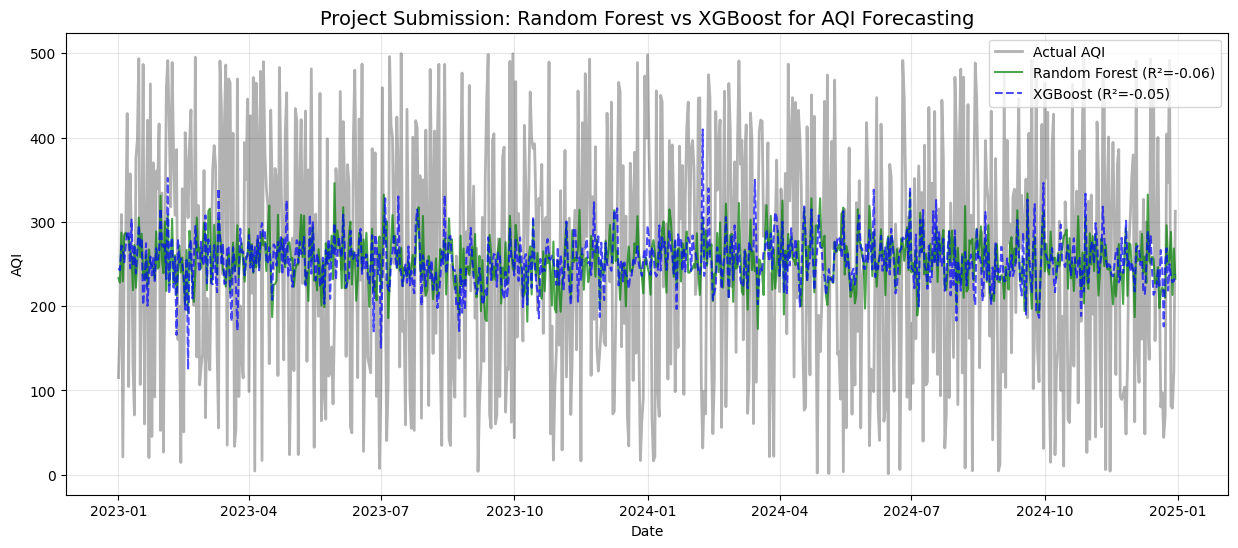

In [25]:
# --- STEP 7: Visualization ---
plt.figure(figsize=(15, 6))
plt.plot(test['Date'], y_test, label='Actual AQI', color='black', alpha=0.3, linewidth=2)
plt.plot(test['Date'], rf_preds, label=f'Random Forest (R²={rf_r2:.2f})', color='green', alpha=0.7)
plt.plot(test['Date'], xgb_preds, label=f'XGBoost (R²={xgb_r2:.2f})', color='blue', alpha=0.7, linestyle='--')

plt.title('Project Submission: Random Forest vs XGBoost for AQI Forecasting', fontsize=14)
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()